<a href="https://colab.research.google.com/github/Bonrice/Google-Colab-Projects/blob/main/Steam_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pyspark.sql import SparkSession

# Increase Spark driver memory to prevent OutOfMemory errors
spark = SparkSession.builder.master("local[*]").config("spark.driver.memory", "16g").getOrCreate()
print("SparkSession created successfully.")
spark

SparkSession created successfully.


In [3]:
from pyspark.sql.functions import col, try_to_timestamp, lit

# Reload reviews DataFrame to ensure it's in the expected state
reviews = spark.read.csv('/content/drive/MyDrive/steam_dataset/reviews.csv', header=True)

# Apply the timestamp conversion to new columns
reviews = reviews.withColumn("review_updated_at", try_to_timestamp(col("updated_at"), lit("yyyy-MM-dd HH:mm:ss.SSSSSSXXX"))) \
.withColumn('review_created_at', try_to_timestamp(col('created_at'), lit('yyyy-MM-dd HH:mm:ss.SSSSSSXXX')))

from IPython.core import application
from pyspark.sql.functions import col, try_to_timestamp, lit

# Reload reviews DataFrame to ensure it's in the expected state
application = spark.read.csv('/content/drive/MyDrive/steam_dataset/applications.csv', header=True)

# Apply the timestamp conversion to new columns
application = application.withColumn("application_updated_at", try_to_timestamp(col("updated_at"), lit("yyyy-MM-dd HH:mm:ss.SSSSSSXXX"))) \
.withColumn('application_created_at', try_to_timestamp(col('created_at'), lit('yyyy-MM-dd HH:mm:ss.SSSSSSXXX')))

In [4]:
merged_df = application.join(reviews, on='appid', how='left')

from pyspark.sql.functions import to_timestamp, col, lit, try_to_timestamp
from pyspark.sql.types import BooleanType, IntegerType, DoubleType, LongType

steam = merged_df.withColumn('author_num_games_owned', col('author_num_games_owned').cast(IntegerType())) \
          .withColumn('author_num_reviews', col('author_num_reviews').cast(DoubleType())) \
          .withColumn('author_playtime_forever', col('author_playtime_forever').cast(DoubleType())) \
          .withColumn('author_playtime_last_two_weeks', col('author_playtime_last_two_weeks').cast(DoubleType())) \
          .withColumn('author_playtime_at_review', col('author_playtime_at_review').cast(DoubleType())) \
          .withColumn('timestamp_created', try_to_timestamp(col('timestamp_created'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('timestamp_updated', try_to_timestamp(col('timestamp_updated'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('weighted_vote_score', col('weighted_vote_score').cast(DoubleType())) \
          .withColumn('comment_count', col('comment_count').cast(DoubleType())) \
          .withColumn('steam_purchase', col('steam_purchase').cast(BooleanType())) \
          .withColumn('received_for_free', col('received_for_free').cast(BooleanType())) \
          .withColumn('written_during_early_access', col('written_during_early_access').cast(BooleanType())) \
          .withColumn('is_free', col('is_free').cast(BooleanType())) \
          .withColumn('release_date', try_to_timestamp(col('release_date'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('required_age', col('required_age').cast(DoubleType())) \
          .withColumn('metacritic_score', col('metacritic_score').cast(DoubleType())) \
          .withColumn('recommendations_total', col('recommendations_total').cast(DoubleType())) \
          .withColumn('mat_supports_windows', col('mat_supports_windows').cast(BooleanType())) \
          .withColumn('mat_supports_mac', col('mat_supports_mac').cast(BooleanType())) \
          .withColumn('mat_supports_linux', col('mat_supports_linux').cast(BooleanType())) \
          .withColumn('mat_initial_price', col('mat_initial_price').cast(DoubleType())) \
          .withColumn('mat_final_price', col('mat_final_price').cast(DoubleType())) \
          .withColumn('mat_discount_percent', col('mat_discount_percent').cast(DoubleType())) \
          .withColumn('mat_achievement_count', col('mat_achievement_count').cast(DoubleType())) \

print('Schema:')
steam.printSchema()

Schema:
root
 |-- appid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- release_date: timestamp (nullable = true)
 |-- required_age: double (nullable = true)
 |-- short_description: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- background: string (nullable = true)
 |-- metacritic_score: double (nullable = true)
 |-- recommendations_total: double (nullable = true)
 |-- mat_supports_windows: boolean (nullable = true)
 |-- mat_supports_mac: boolean (nullable = true)
 |-- mat_supports_linux: boolean (nullable = true)
 |-- mat_initial_price: double (nullable = true)
 |-- mat_final_price: double (nullable = true)
 |-- mat_discount_percent: double (nullable = true)
 |-- mat_currency: string (nullable = true)
 |-- mat_achievement_count: double (nullable = true)
 |-- mat_pc_os_min: string (nullable = true)
 |-- mat_pc_proce

In [5]:
steam = steam.drop('header_image','background','mat_pc_os_min','mat_pc_processor_min','mat_pc_memory_min','mat_pc_graphics_min','mat_pc_os_rec','mat_pc_processor_rec','mat_pc_memory_rec','mat_pc_graphics_rec','created_at','updated_at')

In [6]:
from pyspark.sql.functions import col, lower
from pyspark.sql import functions as F

english = steam.filter(lower(col('language')).contains('english'))
english_bools = english.filter(F.col("voted_up").try_cast("boolean").isNotNull())

In [7]:
training = english_bools.select('appid','name','author_steamid','review_text','voted_up')

from pyspark.sql.functions import col, when

training_binary = training.withColumn(
    "label",
    when(col("voted_up") == True, 1)
    .when(col("voted_up") == False, 0)
    .otherwise(None)  # Preserve nulls
)
training_binary.show()

+-------+--------------------+-----------------+--------------------+--------+-----+
|  appid|                name|   author_steamid|         review_text|voted_up|label|
+-------+--------------------+-----------------+--------------------+--------+-----+
|1000030|Cook, Serve, Deli...|76561198104194625|I do recommend th...|    True|    1|
|1000030|Cook, Serve, Deli...|76561199089284390|Feels like a 9 to...|    True|    1|
|1000030|Cook, Serve, Deli...|76561198002916907|This is an improv...|    True|    1|
|1000030|Cook, Serve, Deli...|76561198981805264|This game was so ...|    True|    1|
|1000030|Cook, Serve, Deli...|76561198963260958|Really fun game, ...|    True|    1|
|1000030|Cook, Serve, Deli...|76561198822806473|Smash keyboard, m...|    True|    1|
|1000030|Cook, Serve, Deli...|76561199122201450|It's very good! A...|    True|    1|
|1000030|Cook, Serve, Deli...|76561198300297476|Adds to the pre-e...|    True|    1|
|1000030|Cook, Serve, Deli...|76561198793295295|I love the variet

In [8]:
import pyspark.sql.functions as F

# Train/Test Split using PySpark's randomSplit
train_steam, test_steam = training_binary.randomSplit([0.8, 0.2], seed=42)

print(f"Number of rows in train_steam: {train_steam.count()}")
print(f"Number of columns in train_steam: {len(train_steam.columns)}")
print(f"Number of rows in test_steam: {test_steam.count()}")
print(f"Number of columns in test_steam: {len(test_steam.columns)}")

Number of rows in train_steam: 271360
Number of columns in train_steam: 6
Number of rows in test_steam: 67797
Number of columns in test_steam: 6


In [9]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import HashingTF, Tokenizer, IDF

# Configure an ML pipeline, which consists of three stages: tokenizer, hashingTF, and lr.
tokenizer = Tokenizer(inputCol="review_text", outputCol="words")
hashingTF = HashingTF(inputCol=tokenizer.getOutputCol(), outputCol="rawfeatures")
lr = LogisticRegression(maxIter=10, regParam=0.001, labelCol="label")
idf = IDF(inputCol=hashingTF.getOutputCol(), outputCol="features")
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, lr])

# Fill nulls in 'review_text' with empty strings before fitting
train_steam_cleaned = train_steam.na.fill('', subset=['review_text'])

# Fit the pipeline to training documents.
model = pipeline.fit(train_steam_cleaned)

In [10]:
import pyspark.sql.functions as F

# Ensure 'review_text' has no nulls by explicitly replacing with empty string
test_steam_cleaned = test_steam.withColumn(
    'review_text', F.coalesce(F.col('review_text'), F.lit(''))
)

# Ensure 'label' has no nulls, as LogisticRegression requires a valid label.
# Null labels would cause issues during evaluation or even during model transformation.
test_steam_cleaned = test_steam_cleaned.filter(F.col('label').isNotNull())

# Cache the cleaned DataFrame to materialize changes before transformation
test_steam_cleaned.cache()

prediction = model.transform(test_steam_cleaned)

In [11]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Force evaluation of predictions
prediction.cache()  # Keep in memory for repeated use
prediction.show(5, truncate=False)  # Show sample predictions to confirm

# Create evaluator
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# Compute ROC AUC
roc_auc = evaluator.evaluate(prediction)

# Safely extract LogisticRegressionModel from pipeline
from pyspark.ml.classification import LogisticRegressionModel

# Find the LR model stage dynamically
lrmodel = None
for stage in model.stages:
    if isinstance(stage, LogisticRegressionModel):
        lrmodel = stage
        break

if lrmodel is None:
    raise ValueError("No LogisticRegressionModel found in pipeline stages.")

# Print results immediately
print("Coefficients:", lrmodel.coefficients)
print("Intercept:", lrmodel.intercept)
print("Area Under ROC:", roc_auc)

# Force flush stdout
import sys
sys.stdout.flush()

+-------+--------------------------------+-----------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

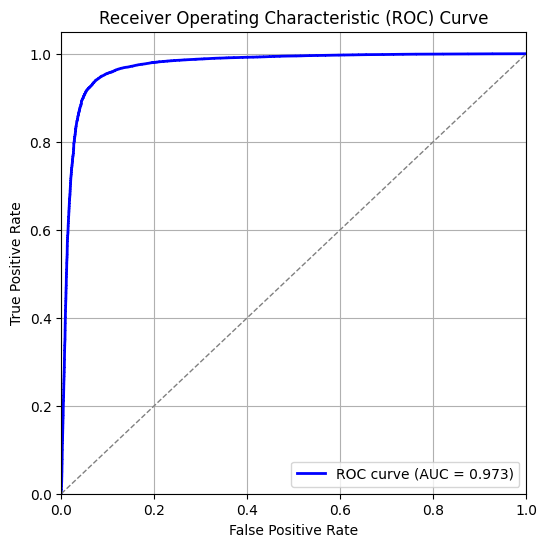

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Step 1: Extract probability and label columns
# probability is a Vector, so we take the probability of class 1
preds = prediction.select("label", "probability").rdd.map(lambda row: (float(row.label), float(row.probability[1])))

# Step 2: Convert to Pandas for sklearn
preds_df = preds.toDF(["label", "probability"]).toPandas()

# Step 3: Compute ROC curve and AUC using sklearn
fpr, tpr, thresholds = roc_curve(preds_df["label"], preds_df["probability"])
roc_auc = auc(fpr, tpr)

# Step 4: Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [13]:
from pyspark.sql.functions import col

# Count correct predictions
correct_preds = prediction.filter(col("label") == col("prediction")).count()

# Count total predictions
total_preds = prediction.count()

# Calculate accuracy
accuracy = correct_preds / total_preds if total_preds > 0 else 0

print(f"Correct Predictions: {correct_preds}")
print(f"Total Predictions: {total_preds}")
print(f"Accuracy: {accuracy:.4f}")

Correct Predictions: 63839
Total Predictions: 67556
Accuracy: 0.9450
